## Importing the relevant libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings, os, random, cv2
warnings.filterwarnings('ignore')
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from PIL import Image
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler, TensorBoard, ModelCheckpoint
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import plot_model, to_categorical
from tqdm.notebook import tqdm
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from sklearn.utils import compute_class_weight

2025-05-27 07:12:23.976099: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748329944.154966      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748329944.206088      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Loading the images

In [2]:
BASE_IMG_DIR = "/kaggle/input/animals10/raw-img"

train_datagen = ImageDataGenerator(rescale=1/255.,validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1/255.,validation_split=0.2)

In [3]:
train_data = train_datagen.flow_from_directory(directory=BASE_IMG_DIR,
                                              target_size=(128,128),
                                              color_mode='rgb',
                                              class_mode='categorical',
                                              shuffle=True)

test_data = test_datagen.flow_from_directory(directory=BASE_IMG_DIR,
                                            target_size=(128,128),
                                            color_mode='rgb',
                                            class_mode='categorical',
                                            shuffle=False)

Found 26179 images belonging to 10 classes.
Found 26179 images belonging to 10 classes.


## Visualizing a sample of images & labels

In [4]:
def visualize_sample_images(data_generator, class_names=None, sample_size=25):
    images, labels = next(data_generator)  # Get one batch
    plt.figure(figsize=(12, 12))
    
    for i in range(min(sample_size, len(images))):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i]) 
        if class_names is not None:
            label_index = int(labels[i]) if labels.ndim == 1 else labels[i].argmax()
            plt.title(class_names[label_index], color='blue', fontsize=10)
        else:
            plt.title(f"Label: {labels[i]}", fontsize=9)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [5]:
classes = list(os.listdir(BASE_IMG_DIR))
classes

['cavallo',
 'pecora',
 'elefante',
 'gatto',
 'scoiattolo',
 'gallina',
 'ragno',
 'mucca',
 'cane',
 'farfalla']

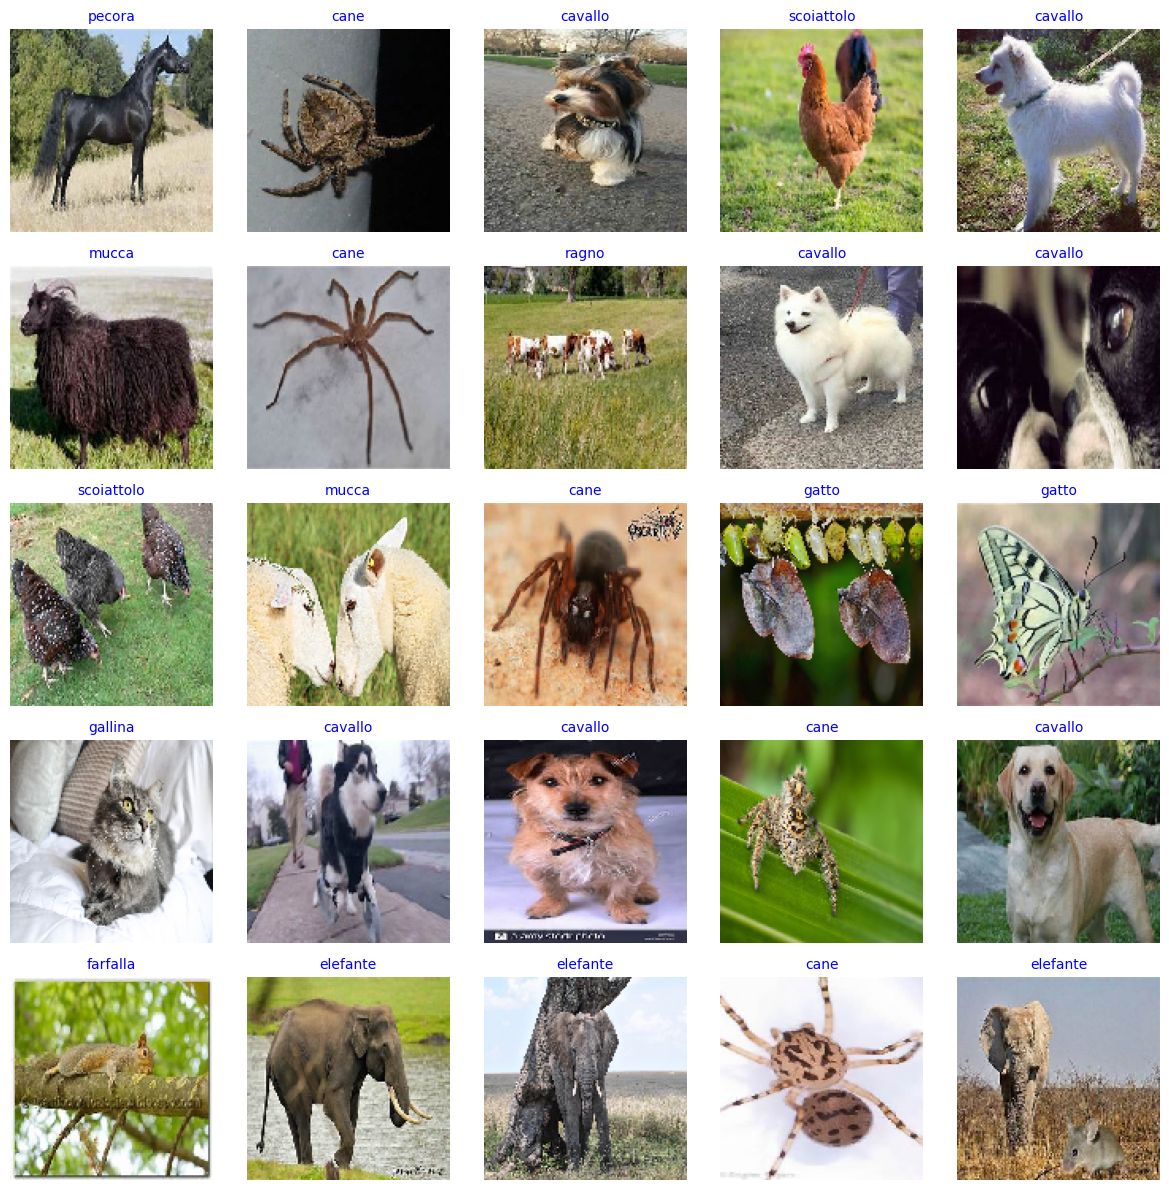

In [6]:
visualize_sample_images(data_generator=train_data,
                       class_names=classes,
                       sample_size=25)

## Defining the model architecture

In [7]:
def create_cnn_model(input_shape,num_classes):
    model = Sequential(name='simplified_animal_detector')

    # Input layer
    model.add(Input(shape=input_shape))

    # Block 1
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())

    # Block 2
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(BatchNormalization())

    # Global average pooling
    model.add(GlobalAveragePooling2D())

    # Dense block
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))

    # Output layer
    model.add(Dense(num_classes, activation='softmax'))
    return model

In [8]:
input_shape = (128,128,3)

model = create_cnn_model(input_shape,len(classes))
model.summary()

I0000 00:00:1748329975.102994      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "simplified_animal_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,546 (131.04 KB)

 Trainable params: 33,354 (130.29 KB)

 Non-trainable params: 192 (768.00 B)

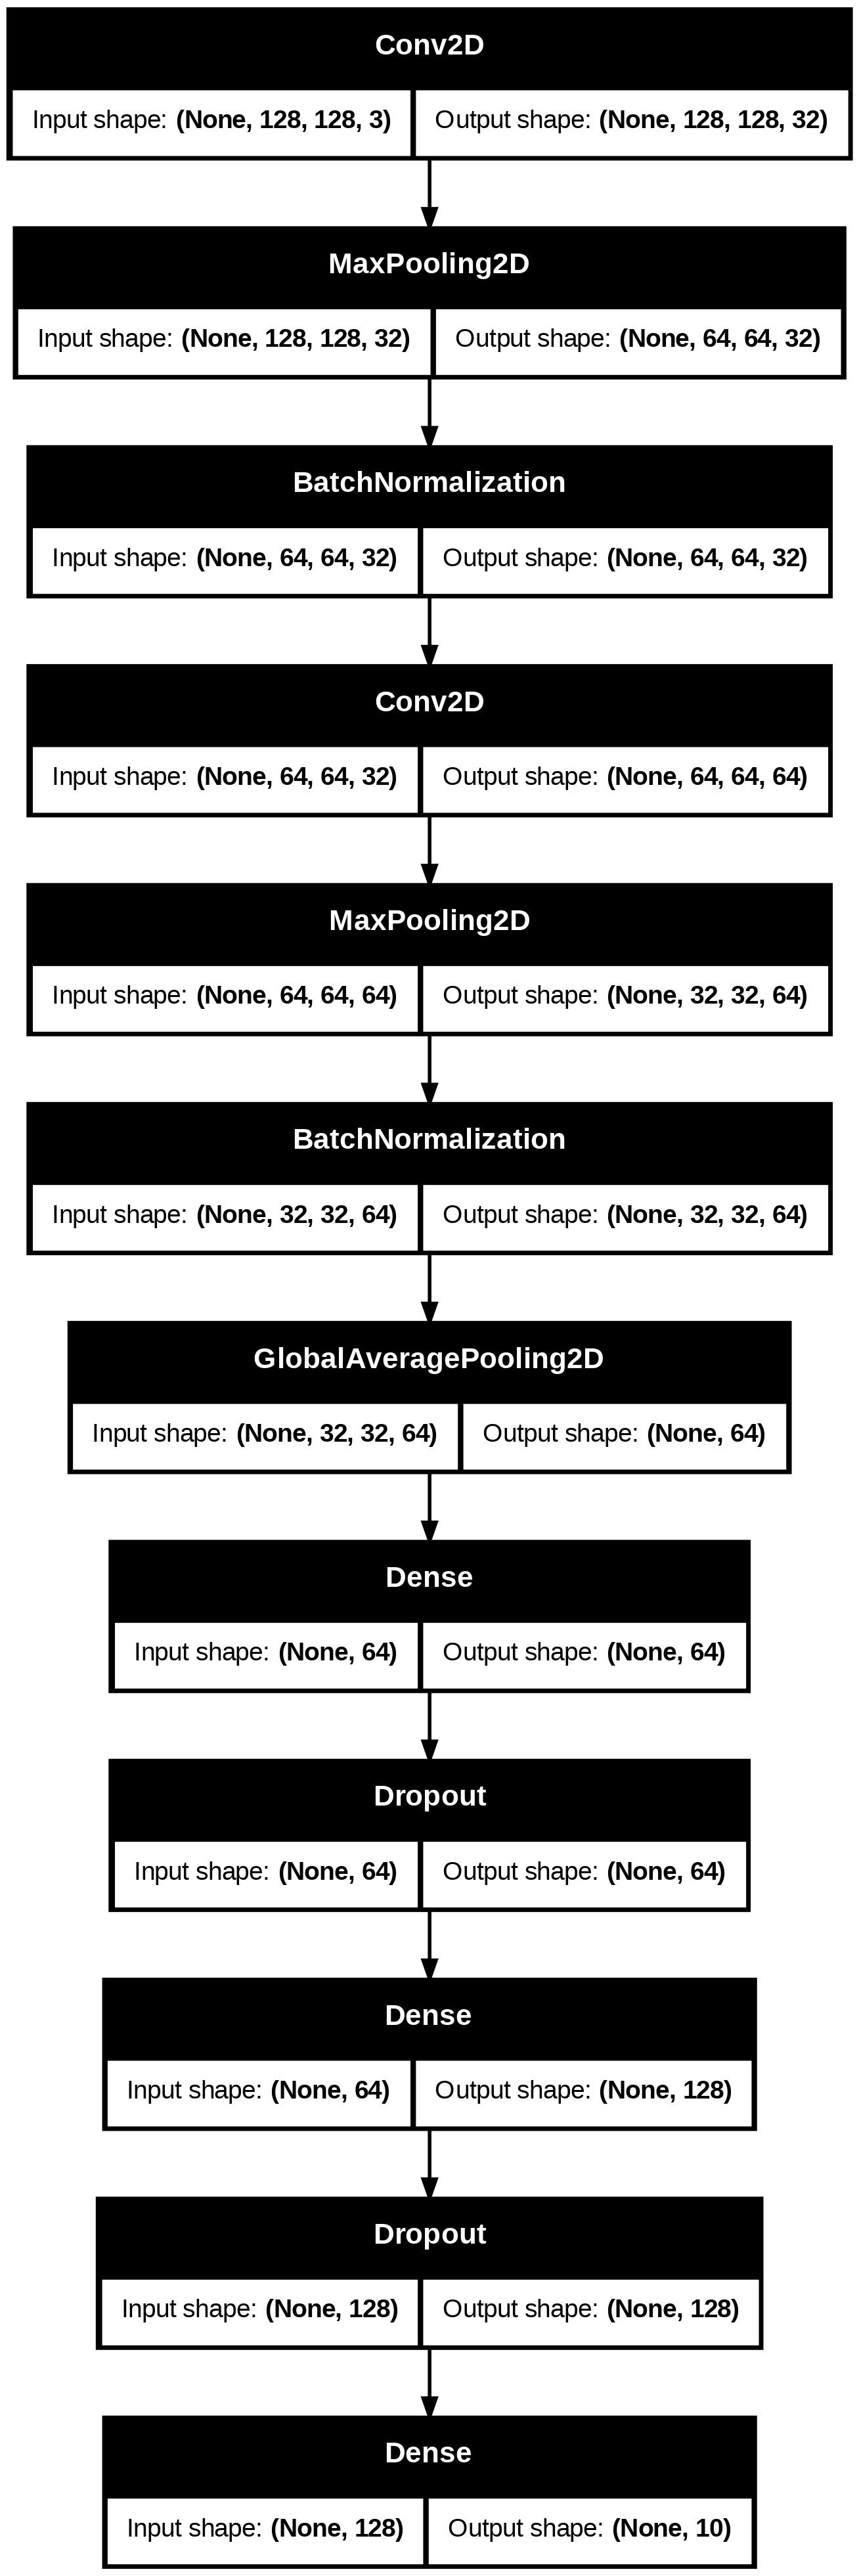

In [9]:
plot_model(model,to_file='model.png',show_shapes=True,dpi=200)

## Model Training & Evaluation

In [10]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [11]:
def gradual_decay_schedule(epoch, lr):
    return max(lr * 0.97, 1e-4)

In [12]:
callbacks = [
    EarlyStopping(monitor='val_accuracy',mode='max',patience=12,start_from_epoch=5,verbose=1,restore_best_weights=True),
    LearningRateScheduler(schedule=gradual_decay_schedule,verbose=1),
    TensorBoard(log_dir='./',histogram_freq=1,write_graph=True,embeddings_freq=1,update_freq='epoch'),
    ModelCheckpoint(filepath='animal_classifier.keras',monitor='val_accuracy',mode='max',save_best_only=True,save_freq='epoch',verbose=1)
]

r = model.fit(
    train_data,
    epochs=100,
    callbacks=callbacks,
    validation_data=test_data,
    verbose=1
)


Epoch 1: LearningRateScheduler setting learning rate to 0.0009700000460725278.
Epoch 1/100


I0000 00:00:1748329981.367979      77 service.cc:148] XLA service 0x30d72000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748329981.368733      77 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1748329981.787020      77 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1748329985.266606      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.2712 - loss: 2.0391
Epoch 1: val_accuracy improved from -inf to 0.24970, saving model to animal_classifier.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 223s 264ms/step - accuracy: 0.2713 - loss: 2.0390 - val_accuracy: 0.2497 - val_loss: 2.2824 - learning_rate: 9.7000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.000940900050336495.
Epoch 2/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3793 - loss: 1.7615
Epoch 2: val_accuracy improved from 0.24970 to 0.36010, saving model to animal_classifier.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 99s 120ms/step - accuracy: 0.3793 - loss: 1.7614 - val_accuracy: 0.3601 - val_loss: 1.8644 - learning_rate: 9.4090e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.000912673061247915.
Epoch 3/100
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4483 - loss: 1.5796
Epoch 3: val_accuracy improved from 0.36010 to 0.36629, saving model to animal_classifier.keras
819/819

## Visualizing model performance

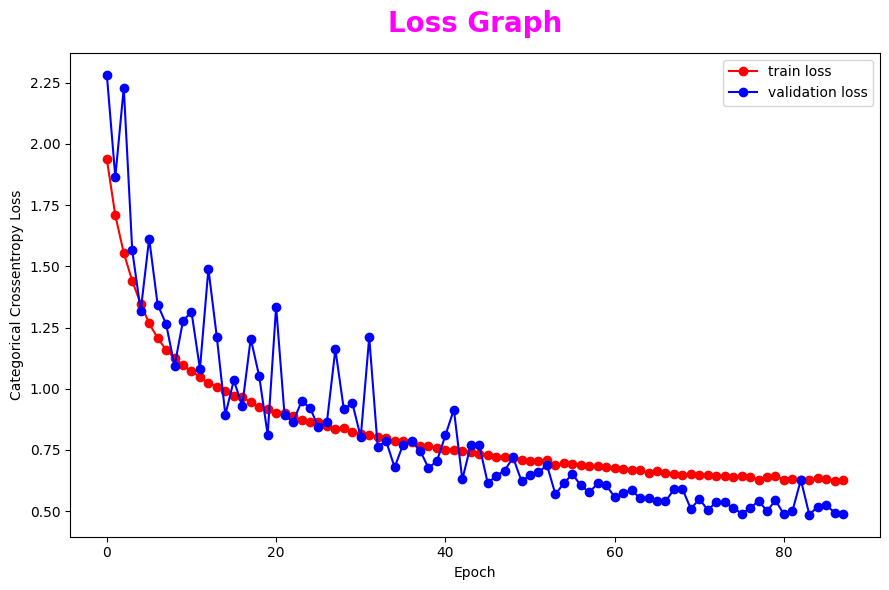

In [13]:
plt.figure(figsize=(9,6))
plt.plot(r.history['loss'],'r',label='train loss',marker='o')
plt.plot(r.history['val_loss'],'b',label='validation loss',marker='o')
plt.title('Loss Graph', fontsize=20, pad=15, color='fuchsia', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Categorical Crossentropy Loss')
plt.legend()
plt.tight_layout()
plt.show();

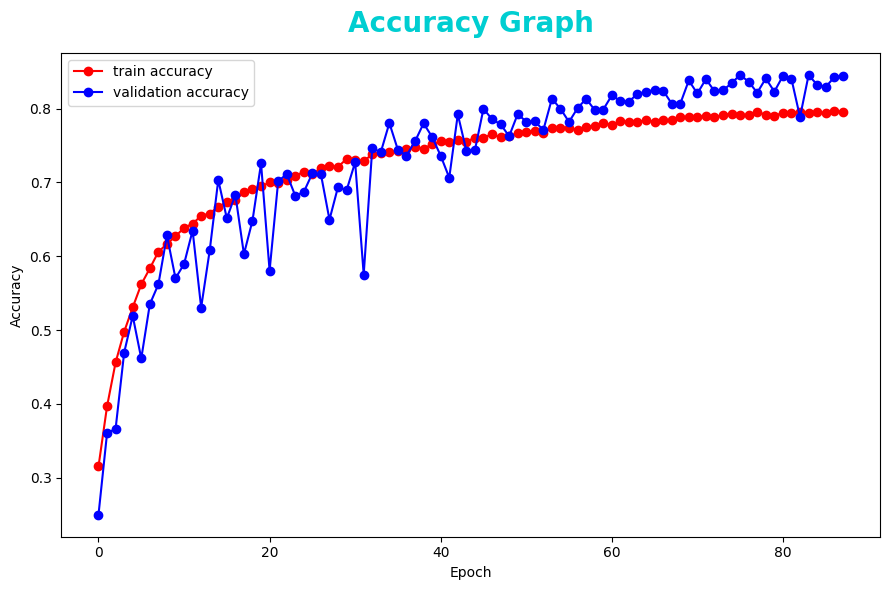

In [14]:
plt.figure(figsize=(9,6))
plt.plot(r.history['accuracy'],'r',label='train accuracy',marker='o')
plt.plot(r.history['val_accuracy'],'b',label='validation accuracy',marker='o')
plt.title('Accuracy Graph', fontsize=20, pad=15, color='darkturquoise', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show();

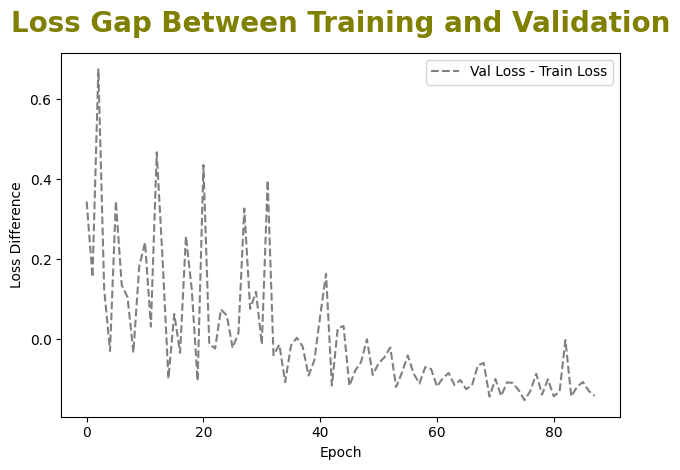

In [15]:
# Checking for Overfitting/Underfitting
diff = np.array(r.history['val_loss']) - np.array(r.history['loss'])
plt.plot(diff, label='Val Loss - Train Loss', color='gray', linestyle='--')
plt.title('Loss Gap Between Training and Validation', fontsize=20, pad=15, color='olive', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss Difference')
plt.legend()
plt.tight_layout()
plt.show();

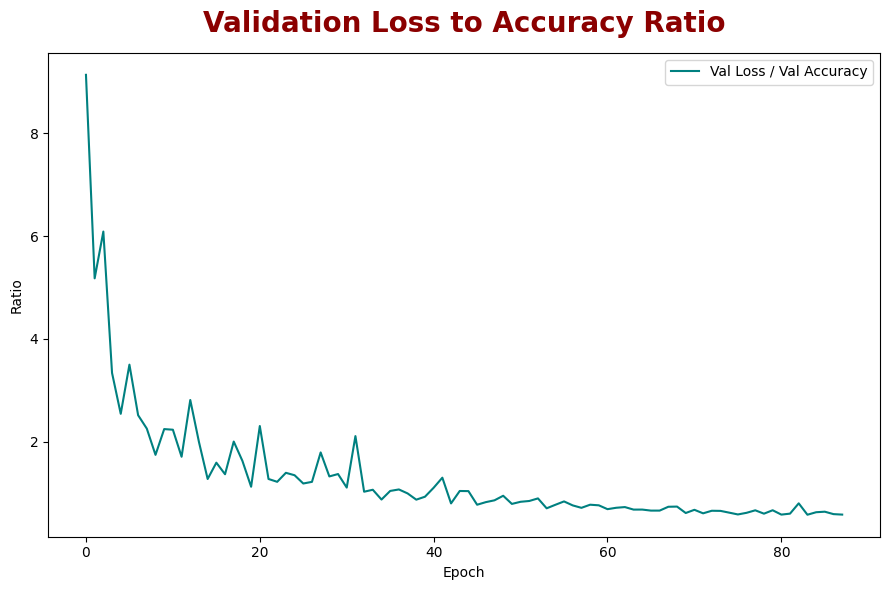

In [16]:
# Validation Loss to Accuracy Ratio
ratio = np.array(r.history['val_loss']) / (np.array(r.history['val_accuracy']) + 1e-8)
plt.figure(figsize=(9,6))
plt.plot(ratio, label='Val Loss / Val Accuracy', color='teal')
plt.title('Validation Loss to Accuracy Ratio', fontsize=20, pad=15, color='darkred', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Ratio')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
def smooth_curve(points, factor=0.8):
    """
        This function uses exponential smoothing to reduce noise in data points.
    """
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

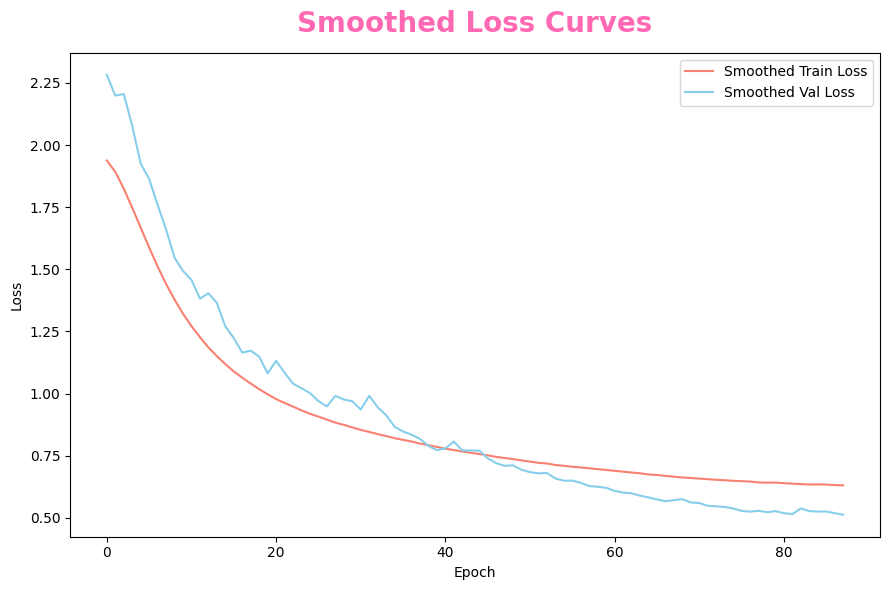

In [18]:
# Smoothed Loss Curve
plt.figure(figsize=(9,6))
plt.plot(smooth_curve(r.history['loss']), label='Smoothed Train Loss', color='salmon')
plt.plot(smooth_curve(r.history['val_loss']), label='Smoothed Val Loss', color='skyblue')
plt.title('Smoothed Loss Curves', fontsize=20, pad=15, color='hotpink', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

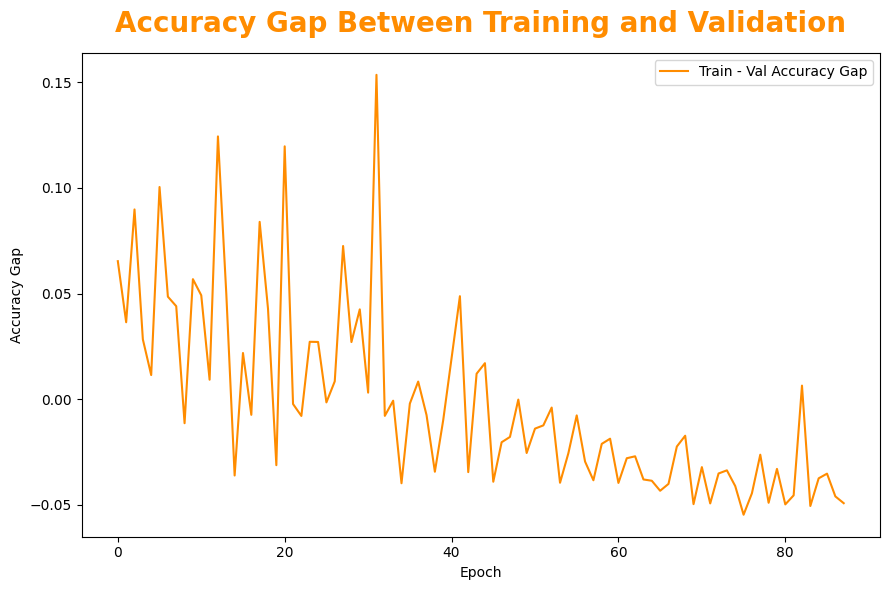

In [19]:
# Relative Accuracy Gap Plot
gap = np.array(r.history['accuracy']) - np.array(r.history['val_accuracy'])
plt.figure(figsize=(9,6))
plt.plot(gap, label='Train - Val Accuracy Gap', color='darkorange')
plt.title('Accuracy Gap Between Training and Validation', fontsize=20, pad=15, color='darkorange', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap')
plt.legend()
plt.tight_layout()
plt.show()

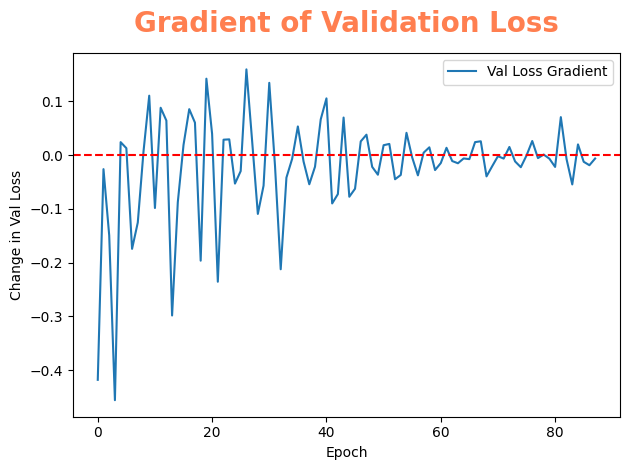

In [20]:
# Convergence Check
loss_grad = np.gradient(r.history['val_loss'])
plt.plot(loss_grad, label='Val Loss Gradient')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Gradient of Validation Loss', fontsize=20, pad=15, color='coral', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Change in Val Loss')
plt.legend()
plt.tight_layout()
plt.show();

In [21]:
loss, acc = model.evaluate(test_data)
print(f"Test Loss: {loss:.3f}")
print(f"Test Accuracy: {acc:.2f}")

819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - accuracy: 0.8441 - loss: 0.5009
Test Loss: 0.490
Test Accuracy: 0.85


In [22]:
val_indices = test_data.index_array
class_indices = test_data.classes

y_test = class_indices[val_indices]

In [23]:
num_classes = test_data.num_classes
y_test_one_hot = to_categorical(y_test,num_classes=num_classes)

In [24]:
y_test.shape

(26179,)

819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step
Confusion Matrix:
[[4172  131   21   16   66  213   63   68   49   64]
 [ 223 2080   31   11   28   16  146   56   16   16]
 [  42   63 1199    1    7   27   20   57   10   20]
 [  15    3    1 1903   24   15    1    0  130   20]
 [ 135   10    2   26 2787   26    3   18   38   53]
 [ 337    2    8   13   10 1192    1   22   37   46]
 [ 192  139   10    2   26    3 1326  158    5    5]
 [ 117   20   31    0   33   81   75 1430    5   28]
 [  37    6    3  113   19   53    0    5 4521   64]
 [  75    2    3   19   23   95    0   13   99 1533]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.86      0.82      4863
           1       0.85      0.79      0.82      2623
           2       0.92      0.83      0.87      1446
           3       0.90      0.90      0.90      2112
           4       0.92      0.90      0.91      3098
           5       0.69      0.71      0.70      1668
      

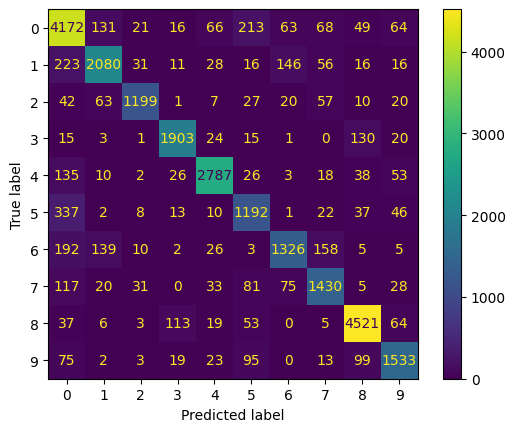

In [25]:
test_predictions = model.predict(test_data)
test_predictions = np.argmax(test_predictions,axis=1)
print("Confusion Matrix:")
print(confusion_matrix(y_test,test_predictions))
print("Classification Report:")
print(classification_report(y_test,test_predictions))
ConfusionMatrixDisplay.from_predictions(y_test,test_predictions)
plt.show()

## Model Inference

In [26]:
def predict_on_sample_image(input_img_file,model,class_labels):
    image = cv2.imread(input_img_file)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    image = cv2.resize(image,(128,128))
    image = image / 255.
    image = np.expand_dims(image,axis=0)

    prediction = model.predict(image,verbose=0)
    predicted_class = np.argmax(prediction,axis=-1)[0]
    class_name = class_labels[predicted_class]

    plt.imshow(image[0])
    plt.axis('off')
    plt.title(f"Prediction: {class_name} Confidence Score: {np.max(prediction):.2f}",fontsize=18,fontweight='bold',color='magenta',pad=20)
    plt.show();

In [27]:
image_label_mapping = {idx: value for idx, value in enumerate(classes)}
image_label_mapping

{0: 'cavallo',
 1: 'pecora',
 2: 'elefante',
 3: 'gatto',
 4: 'scoiattolo',
 5: 'gallina',
 6: 'ragno',
 7: 'mucca',
 8: 'cane',
 9: 'farfalla'}

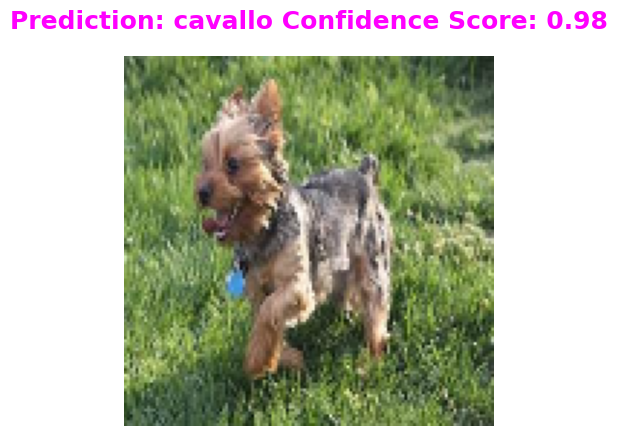

In [28]:
random_class = random.choice(os.listdir(BASE_IMG_DIR))
class_path = os.path.join(BASE_IMG_DIR, random_class)
random_img = random.choice(os.listdir(class_path))
sample_test_image = os.path.join(class_path, random_img)
predict_on_sample_image(sample_test_image, model, image_label_mapping)